<!-- ============================================================ -->
<!-- NOTEBOOK HEADER — MLOps Introductory Course on GCP           -->
<!-- ============================================================ -->

<div style="border-bottom: 3px solid #4285F4; padding-bottom: 12px; margin-bottom: 20px;">

<div style="display: flex; align-items: center; justify-content: space-between;">
  <div>
    <img src="https://www.isae-supaero.fr/wp-content/uploads/2025/03/logo.svg" width="180">
  </div>
  <div style="text-align: right;">
    <img src="https://user-images.githubusercontent.com/63151412/167391313-4683cc69-2bf6-4597-b767-5c18e2bbbfa0.png" width="180">
  </div>
</div>

# Lab 01 — MLflow: Experiment Tracking — ✅ Solution

**Course:** MLOps Introductory Course on GCP · M2 Data Science · ISAE-SUPAERO  
**Lab created by:** Headmind Partners AI & Blockchain  
**Estimated duration:** ~2h30

</div>

## 📋 Lab Overview

### Learning Objectives

By the end of this lab, you will be able to:

1. **Launch and connect to an MLflow tracking server**
2. **Log parameters, metrics, and artifacts** to MLflow experiments
3. **Compare runs** using the MLflow UI
4. **Automate hyperparameter search** with Optuna, tracked by MLflow
5. **Register and version models** in the MLflow Model Registry
6. **Load a registered model** programmatically for inference

### Business Context

**Credit risk** is the risk that a borrower fails to repay a loan. Banks build credit-risk models to minimize expected losses, and machine learning classifiers can help predict whether a customer is likely to default.

In this lab you will work with the [German Credit Risk dataset](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data) (UCI), which contains anonymized profiles of 1 000 bank customers. Your job is to build a classifier that predicts whether a customer is **creditworthy** (`0`) or **at risk** (`1`).

### Why MLflow?

In production ML, tracking experiments is crucial. Without proper tracking:
- You can't reproduce results
- You lose track of which hyperparameters worked best
- Collaboration becomes chaotic
- Model deployment becomes error-prone

MLflow solves these problems by providing a unified platform for the ML lifecycle.

### Notebook Structure

| # | Section | Focus |
|---|---------|-------|
| 0 | Setup | Install dependencies, start MLflow server, connect |
| 1 | Data Exploration | Load data, EDA, class balance analysis |
| 2 | Feature Engineering | Identify and encode categorical features |
| 3 | Baseline Model + MLflow Logging | Train a default Random Forest, log everything to MLflow |
| 4 | Manual Tuning + MLflow Comparison | Tweak hyperparameters by hand, compare runs in the UI |
| 5 | Automated Tuning with Optuna | Use Optuna for systematic search, nested MLflow runs |
| 6 | Model Registry | Register, version, and load the best model |

### How to Read This Notebook

- **`# TODO`** — Code you need to write. Look for the `######` delimiters.
- **`✏️ Question`** — A conceptual question. Write your answer in the markdown cell below it.
- Cells **without** a TODO are provided — read them, run them, and make sure you understand them.
- Documentation links are provided in 📖 callouts whenever a new API is introduced.

---
## 0 · Setup

### 0.1 Install dependencies

Make sure that you have a virtual environment created for this lab (See README.md installation guide - Step 2). Select this venv for the notebook kernel.

In [ ]:
%pip install -r requirements.txt -q

### 0.2 Imports

In [1]:
import pickle
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import mlflow
from mlflow import MlflowClient
import optuna

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42          # reproducibility
TEST_SIZE = 0.20           # 80/20 split
VAL_SIZE = 0.20            # 20 % of training set for validation

print(f"MLflow version: {mlflow.__version__}")
print(f"Optuna version: {optuna.__version__}")

MLflow version: 3.8.1
Optuna version: 4.7.0


### 0.3 Start the MLflow Tracking Server

Before running the rest of this notebook, **open a terminal**, activate this lab's virtual environment and start a local MLflow server:

```bash
mlflow server --host 127.0.0.1 --port 8080
```

Then open the UI in your browser at [http://127.0.0.1:8080](http://127.0.0.1:8080).

> 📖 **Docs:** [MLflow Tracking Server](https://mlflow.org/docs/latest/tracking/server.html)

💡 **Tip**: Keep this terminal open throughout the lab. The MLflow server must be running to track experiments.

In [2]:
# ✅ SOLUTION
MLFLOW_HOST = "127.0.0.1"
MLFLOW_PORT = "8080"

TRACKING_URI = f"http://{MLFLOW_HOST}:{MLFLOW_PORT}"
mlflow.set_tracking_uri(TRACKING_URI)
print(f"Tracking URI set to: {TRACKING_URI}")

Tracking URI set to: http://127.0.0.1:8080


---
## 1 · Data Exploration

### 1.1 Load the dataset

In [3]:
df = pd.read_parquet("data/dataset.parquet")
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 21)


,checking_account_status,duration_month,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence_since,property,age,other_installment_plans,housing,existing_credits_count,job,dependents_count,telephone,foreign_worker,class
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,A65,.. >= 7 years,4,male : single,none,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,A61,1 <= ... < 4 years,2,female : divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee / official,1,none,yes,2
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,A61,4 <= ... < 7 years,2,male : single,none,3,real estate,49,none,own,1,unskilled - resident,2,none,yes,1
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,A61,4 <= ... < 7 years,2,male : single,guarantor,4,building society savings agreement/life insurance,45,none,for free,1,skilled employee / official,2,none,yes,1
4,< 0 DM,24,delay in paying off in the past,car (new),4870,A61,1 <= ... < 4 years,3,male : single,none,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account_status  1000 non-null   object
 1   duration_month           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_account          1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence_since  1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

### 1.2 Identify the target

The goal is to predict whether a bank should grant credit to a customer.

**✏️ TODO:** Look at the column names and values. Which column is the target?

In [5]:
# ✅ SOLUTION
target_field = "class"

In [6]:
# Rename and remap: 1 → 0 (creditworthy), 2 → 1 (at risk)
df = df.rename(columns={target_field: "risk"})
df["risk"] = df["risk"].map({1: 0, 2: 1})

# Separate features and target
y = df["risk"]
X = df.drop(columns=["risk"])

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print(f"Target distribution:\n{y.value_counts(normalize=True).round(3)}")

Features: 20  |  Samples: 1000
Target distribution:
0    0.7
1    0.3
Name: risk, dtype: float64


This is a **binary classification** problem:
- `risk = 0` → customer is creditworthy
- `risk = 1` → customer is at risk of default

### 1.3 Exploratory Data Analysis

#### Correlation matrix (numeric features only)

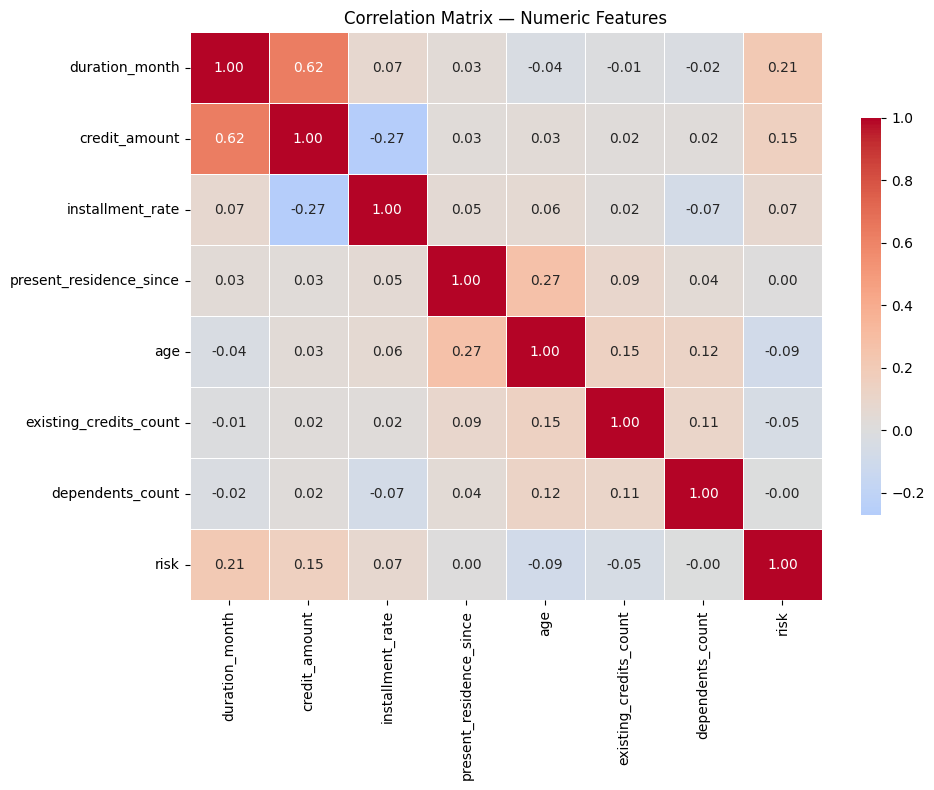

In [7]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5,
            cbar_kws={"shrink": 0.7}, center=0)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

#### Class distribution

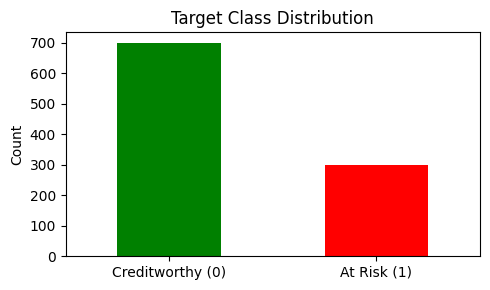

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
y.value_counts().plot(kind="bar", color=["g", "r"], ax=ax)
ax.set_xticklabels(["Creditworthy (0)", "At Risk (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Target Class Distribution")
plt.tight_layout()
plt.show()

**✏️ Question 1 — Class imbalance**

a) Is this dataset balanced? Compute the exact class proportions.  
b) What risks does class imbalance pose for a classifier?  
c) Name **two** techniques you could use to handle imbalance (you don't need to implement them here).

---
*✅ Solution:*

a) The dataset is **moderately imbalanced**: ~70% creditworthy (class 0) and ~30% at risk (class 1).

b) The classifier tends to **favor the majority class**, potentially missing risky customers. In credit risk, false negatives are expensive.

c) (1) **Oversampling** (e.g., SMOTE) or undersampling. (2) Using **class weights** (`class_weight="balanced"` in scikit-learn). (3) Using F1-score/AUC instead of accuracy

---

**✏️ Question 2 — From binary to multi-level risk**

In practice, banks use more granular risk categories (e.g., AAA, AA, A, BBB, …). Given a binary classifier that outputs probabilities, how could you derive *n* risk levels from it? Give a concrete example with n = 4.

---
*✅ Solution:*

Use **probability binning** on `predict_proba()` output. Example with n=4:
- P < 0.25 → Very Low Risk
- 0.25 ≤ P < 0.50 → Low Risk
- 0.50 ≤ P < 0.75 → High Risk
- P ≥ 0.75 → Very High Risk

Thresholds should be calibrated to business costs.

---

---
## 2 · Feature Engineering

We need to encode categorical features before training a tree-based model.

> 📖 **Docs:** [`sklearn.preprocessing.OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

In [9]:
# Separate numeric and categorical columns
numeric_feat = X.select_dtypes(include="number").columns.tolist()
categorical_feat = X.select_dtypes(exclude="number").columns.tolist()

print(f"Numeric features ({len(numeric_feat)}): {numeric_feat}")
print(f"Categorical features ({len(categorical_feat)}): {categorical_feat}")

Numeric features (7): ['duration_month', 'credit_amount', 'installment_rate', 'present_residence_since', 'age', 'existing_credits_count', 'dependents_count']
Categorical features (13): ['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


**✏️ TODO:** Create a OneHotEncoder instance

In [10]:
# One-hot encode and build the final feature matrix
onehot_encoder = OneHotEncoder(sparse_output=True, handle_unknown="ignore")
X_enc_array = onehot_encoder.fit_transform(X[categorical_feat])

X_enc = pd.DataFrame(
    X_enc_array.toarray(),
    columns=onehot_encoder.get_feature_names_out(input_features=categorical_feat),
)
X_enc[numeric_feat] = X[numeric_feat].values  # add numeric features back

print(f"Encoded feature matrix shape: {X_enc.shape}")
X_enc.head()

Encoded feature matrix shape: (1000, 61)


,checking_account_status_0 <= ... < 200 DM,checking_account_status_< 0 DM,checking_account_status_>= 200 DM / salary assignments for at least 1 year,checking_account_status_no checking account,credit_history_all credits at this bank paid back duly,credit_history_critical account/ other credits existing (not at this bank),credit_history_delay in paying off in the past,credit_history_existing credits paid back duly till now,credit_history_no credits taken/ all credits paid back duly,purpose_business,purpose_car (new),purpose_car (used),purpose_domestic appliances,purpose_education,purpose_furniture/equipment,purpose_others,purpose_radio/television,purpose_repairs,purpose_retraining,savings_account_A61,savings_account_A62,savings_account_A63,savings_account_A64,savings_account_A65,employment_duration_.. >= 7 years,...,property_building society savings agreement/life insurance,"property_car or other, not in attribute 6",property_real estate,property_unknown / no property,other_installment_plans_bank,other_installment_plans_none,other_installment_plans_stores,housing_for free,housing_own,housing_rent,job_management/ self-employed/highly qualified employee/ officer,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,telephone_none,"telephone_yes, registered under the customers name",foreign_worker_no,foreign_worker_yes,duration_month,credit_amount,installment_rate,present_residence_since,age,existing_credits_count,dependents_count
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,6,1169,4,4,67,2,1
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,48,5951,2,2,22,1,1
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,12,2096,2,3,49,1,2
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,42,7882,2,4,45,1,2
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,24,4870,3,4,53,2,2


In [11]:
# Save the encoder — we will log it as an MLflow artifact later
with open("data/one_hot_encoder.pkl", "wb") as f:
    pickle.dump(onehot_encoder, f)
print("Encoder saved to data/one_hot_encoder.pkl")

Encoder saved to data/one_hot_encoder.pkl


**✏️ Question 3 — One-hot encoding**

a) In one sentence, what does one-hot encoding do?  
b) How would `['Cat', 'Cat', 'Dog', 'Cat', 'Bird', 'Dog']` be transformed?  

---
*✅ Solution:*

a) One-hot encoding converts each categorical value into a binary vector with a `1` at the position for that category and `0` elsewhere.

b) `['Cat','Cat','Dog','Cat','Bird','Dog']` → 3 columns (Bird, Cat, Dog):
```
Cat  → [0, 1, 0]
Cat  → [0, 1, 0]
Dog  → [0, 0, 1]
Cat  → [0, 1, 0]
Bird → [1, 0, 0]
Dog  → [0, 0, 1]
```

---

---
## 3 · Baseline Model + MLflow Logging

### 3.1 Train / Test Split

> 📖 **Docs:** [`sklearn.model_selection.train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

**✏️ TODO:** Split `X_enc` and `y` into training and test sets. Use `stratify=y` so that the class proportions are preserved in both sets.

In [12]:
# ✅ SOLUTION
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print(f"Train risk ratio: {y_train.mean():.3f}  |  Test risk ratio: {y_test.mean():.3f}")

Train: 800 samples  |  Test: 200 samples
Train risk ratio: 0.300  |  Test risk ratio: 0.300


### 3.2 Train a baseline Random Forest (default hyperparameters)

> 📖 **Docs:** [`sklearn.ensemble.RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [13]:
rf_baseline = RandomForestClassifier(random_state=RANDOM_STATE)
rf_baseline.fit(X_train, y_train)

y_pred_proba = rf_baseline.predict_proba(X_test)[:, 1]
y_pred = rf_baseline.predict(X_test)

print(f"Baseline AUC:      {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Baseline F1-score: {f1_score(y_test, y_pred):.4f}")

Baseline AUC:      0.7805
Baseline F1-score: 0.5102


### 3.3 Log the baseline run to MLflow

This is the core of this lab: we will log **parameters**, **metrics**, the **model**, and an **artifact** (our encoder) to MLflow.

> 📖 **Key MLflow functions:**
> - [`mlflow.set_experiment()`](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.set_experiment)
> - [`mlflow.start_run()`](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.start_run)
> - [`mlflow.log_param()`](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.log_param) / [`mlflow.log_params()`](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.log_params)
> - [`mlflow.log_metric()`](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.log_metric)
> - [`mlflow.sklearn.log_model()`](https://mlflow.org/docs/latest/python_api/mlflow.sklearn.html#mlflow.sklearn.log_model)
> - [`mlflow.log_artifact()`](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.log_artifact)

In [14]:
EXPERIMENT_NAME = "credit-risk-classification"
mlflow.set_experiment(experiment_name=EXPERIMENT_NAME)

with mlflow.start_run(run_name="baseline_random_forest"):
    # --- Log hyperparameters ---
    params = rf_baseline.get_params()
    mlflow.log_param("n_estimators", params["n_estimators"])
    mlflow.log_param("max_depth", params["max_depth"])
    mlflow.log_param("min_samples_leaf", params["min_samples_leaf"])
    mlflow.log_param("bootstrap", params["bootstrap"])

    # --- Log metrics ---
    mlflow.log_metric("auc", roc_auc_score(y_test, y_pred_proba))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred))

    # --- Log the model ---
    mlflow.sklearn.log_model(
        rf_baseline,
        name="model",
        registered_model_name="credit-risk-rf",
    )

    # --- Log the encoder as an artifact ---
    mlflow.log_artifact(local_path="data/one_hot_encoder.pkl")

    print("✅ Baseline run logged to MLflow.")

2026/03/04 11:51:35 INFO mlflow.tracking.fluent: Experiment with name 'credit-risk-classification' does not exist. Creating a new experiment.
Successfully registered model 'credit-risk-rf'.
2026/03/04 11:51:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit-risk-rf, version 1
Created version '1' of model 'credit-risk-rf'.


✅ Baseline run logged to MLflow.
🏃 View run baseline_random_forest at: http://127.0.0.1:8080/#/experiments/1/runs/e62a1ff81c4345e3b81e64115d4c6af2
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


**👉 Now open the MLflow UI** ([http://127.0.0.1:8080](http://127.0.0.1:8080)) and explore your run.

**✏️ Question 4 — Navigate the MLflow UI**

Using the MLflow UI, answer the following:

a) What are the default values for `n_estimators`, `max_depth`, and `bootstrap` logged for the baseline run?  
b) Describe the path you followed in the UI to find them (e.g., *Experiments → … → …*).

---
*✅ Solution:*

a) Defaults: `n_estimators`=100, `max_depth`=None, `bootstrap`=True, `min_samples_leaf`=1.

b) UI path: **Experiments** → **credit-risk-classification** → click **baseline_random_forest** run → **Parameters** section.

---

---
## 4 · Manual Tuning + MLflow Comparison

Now let's see if we can improve the baseline by **manually** adjusting a few hyperparameters.

**✏️ TODO:** Choose your own values for the hyperparameters below. Run the cell **at least 2–3 times** with different configurations, then compare all runs in the MLflow UI.

> 💡 **Tip:** After running the cell multiple times, go to the MLflow UI, select multiple runs, and click **Compare** to see a side-by-side table of parameters and metrics.

In [15]:
# ✅ SOLUTION — Example with one configuration.
# Students should run this cell multiple times with different values.
manual_params = {
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_leaf": 3,
    "bootstrap": True,
}

rf_manual = RandomForestClassifier(**manual_params, random_state=RANDOM_STATE)
rf_manual.fit(X_train, y_train)

y_pred_proba = rf_manual.predict_proba(X_test)[:, 1]
y_pred = rf_manual.predict(X_test)
auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

mlflow.set_experiment(experiment_name=EXPERIMENT_NAME)
with mlflow.start_run(run_name="manual_tuning"):
    mlflow.log_params(manual_params)
    mlflow.log_metric("auc", auc)
    mlflow.log_metric("f1_score", f1)
    mlflow.sklearn.log_model(
        rf_manual, 
        name="model",
        registered_model_name="credit-risk-rf",
    )
    mlflow.log_artifact(local_path="data/one_hot_encoder.pkl")

print(f"AUC: {auc:.4f}  |  F1: {f1:.4f}")
print("✅ Manual tuning run logged.")

Registered model 'credit-risk-rf' already exists. Creating a new version of this model...
2026/03/04 11:51:44 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit-risk-rf, version 2
Created version '2' of model 'credit-risk-rf'.


🏃 View run manual_tuning at: http://127.0.0.1:8080/#/experiments/1/runs/b64cbca2182d4cd5ad407be1e8a23795
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1
AUC: 0.7940  |  F1: 0.5567
✅ Manual tuning run logged.


**✏️ Question 5 — Manual tuning observations**

a) Which hyperparameter combination gave you the best F1-score so far?  
b) Why is manual tuning tedious and potentially unreliable?

---
*✅ Solution:*

a) Varies per student — report best combination and metrics from MLflow UI.

b) Manual tuning is tedious because the space is large/multi-dimensional, human intuition is unreliable with parameter interactions, and it's slow and not reproducible. This motivates Optuna/grid search/random search.

---

---
## 5 · Automated Tuning with Optuna

[Optuna](https://optuna.readthedocs.io/en/stable/) is an automatic hyperparameter optimization framework. It uses smart search strategies (e.g., Tree-structured Parzen Estimators) instead of brute-force grid search.

> 📖 **Docs:** [Optuna — Key Concepts](https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/001_first.html)

### 5.1 Create a validation split

We split the **training set** further into train and validation. The validation set is used by Optuna to score each trial. The test set remains untouched until final evaluation.

In [16]:
X_train_opt, X_val, y_train_opt, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
print(f"Optuna train: {X_train_opt.shape[0]}  |  Validation: {X_val.shape[0]}  |  Test: {X_test.shape[0]}")

Optuna train: 640  |  Validation: 160  |  Test: 200


**✏️ Question 6 — Train / Validation / Test**

a) Explain in your own words the role of each split: train, validation, and test.  
b) What happens if the validation set and test set overlap?

---
*✅ Solution:*

a) **Train**: fits model parameters. **Validation**: evaluates hyperparameter candidates (model doesn't train on it, but tuning "sees" it). **Test**: held out for unbiased final evaluation.

b) Overlap = **data leakage**: hyperparameters are indirectly optimized on test data, making metrics overly optimistic.

---

### 5.2 Define the Optuna objective

**✏️ TODO:** Fill in the hyperparameter search ranges. Use the [Optuna `suggest_*` API](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html):
- `trial.suggest_int(name, low, high)`
- `trial.suggest_float(name, low, high)`
- `trial.suggest_categorical(name, choices)`

In [17]:
# ✅ SOLUTION
def objective_parent(trial):
    """Optuna objective: train a RF with suggested params, return F1."""
    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
        params = {
            "n_estimators":    trial.suggest_int("n_estimators", low=10, high=250),
            # "bootstrap":       trial.suggest_categorical("bootstrap", [True, False]),
            "max_depth":       trial.suggest_int("max_depth", low=2, high=30),
            "max_features":    trial.suggest_categorical("max_features", ["sqrt", None]),
            "min_samples_leaf": trial.suggest_float("min_samples_leaf", low=0.001, high=0.1),
            # "min_samples_leaf": trial.suggest_int("min_samples_leaf", low=1, high=10),
        }

        clf = RandomForestClassifier(random_state=RANDOM_STATE)
        clf.set_params(**params)
        
        clf.fit(X_train_opt, y_train_opt)

        y_val_pred = clf.predict(X_val)
        y_val_proba = clf.predict_proba(X_val)[:, 1]

        score = f1_score(y_val, y_val_pred)

        mlflow.log_params(params)
        mlflow.log_metric("val_f1_score", score)
        mlflow.log_metric("val_auc", roc_auc_score(y_val, y_val_proba))

        return score

### 5.3 Run the optimization

We run 30 trials within a parent MLflow run. Each trial is logged as a nested child run.

In [18]:
study = optuna.create_study(direction="maximize")

mlflow.set_experiment(experiment_name=EXPERIMENT_NAME)

with mlflow.start_run(run_name="optuna_search"):
    study.optimize(objective_parent, n_trials=30, timeout=600)

best_params = study.best_trial.params
print(f"\n🏆 Best trial F1: {study.best_trial.value:.4f}")
print(f"Best params: {best_params}")

[I 2026-03-04 11:51:51,037] A new study created in memory with name: no-name-5c7b26d6-62d1-43c7-9ecc-2fee9e76d05c
[I 2026-03-04 11:51:51,460] Trial 0 finished with value: 0.11538461538461539 and parameters: {'n_estimators': 73, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 0.033656903785018163}. Best is trial 0 with value: 0.11538461538461539.


🏃 View run trial_0 at: http://127.0.0.1:8080/#/experiments/1/runs/236667d3a5e24beb80bd6267e9874f04
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


[I 2026-03-04 11:51:51,900] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 185, 'max_depth': 26, 'max_features': 'sqrt', 'min_samples_leaf': 0.09769981326714844}. Best is trial 0 with value: 0.11538461538461539.


🏃 View run trial_1 at: http://127.0.0.1:8080/#/experiments/1/runs/224cacfa757a4662aeccf8cbc1a5f8ac
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


[I 2026-03-04 11:51:52,365] Trial 2 finished with value: 0.3855421686746988 and parameters: {'n_estimators': 108, 'max_depth': 22, 'max_features': None, 'min_samples_leaf': 0.05139135007228277}. Best is trial 2 with value: 0.3855421686746988.


...

🏃 View run trial_27 at: http://127.0.0.1:8080/#/experiments/1/runs/cfa47fadf2e14cd693004e551103260d
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


[I 2026-03-04 11:52:04,152] Trial 28 finished with value: 0.36585365853658536 and parameters: {'n_estimators': 249, 'max_depth': 16, 'max_features': None, 'min_samples_leaf': 0.04652748501169971}. Best is trial 14 with value: 0.47191011235955055.


🏃 View run trial_28 at: http://127.0.0.1:8080/#/experiments/1/runs/7beeb1dc3816443bb176a1fe35f3a94f
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1
🏃 View run trial_29 at: http://127.0.0.1:8080/#/experiments/1/runs/3346348238d84416a0e1db957e85282f
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


[I 2026-03-04 11:52:04,350] Trial 29 finished with value: 0.13333333333333333 and parameters: {'n_estimators': 10, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 0.03381175421549044}. Best is trial 14 with value: 0.47191011235955055.


🏃 View run optuna_search at: http://127.0.0.1:8080/#/experiments/1/runs/fa5f7141695545309de9a8d99dfd2741
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1

🏆 Best trial F1: 0.4719
Best params: {'n_estimators': 13, 'max_depth': 16, 'max_features': None, 'min_samples_leaf': 0.031039159349528698}


### 5.4 Retrain with the best parameters on full training data

Now that Optuna has found the best hyperparameters, we retrain on the **combined** train + validation sets and evaluate on the **held-out test set**.

In [19]:
# Recombine train + validation
X_train_full = pd.concat([X_train_opt, X_val])
y_train_full = pd.concat([y_train_opt, y_val])

# Train final model
rf_best = RandomForestClassifier(**best_params, random_state=RANDOM_STATE)
rf_best.fit(X_train_full, y_train_full)

# Evaluate on test set
y_test_pred = rf_best.predict(X_test)
y_test_proba = rf_best.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_test_proba)
final_f1 = f1_score(y_test, y_test_pred)

print(f"Final Test AUC:      {final_auc:.4f}")
print(f"Final Test F1-score: {final_f1:.4f}")

Final Test AUC:      0.7263
Final Test F1-score: 0.4444


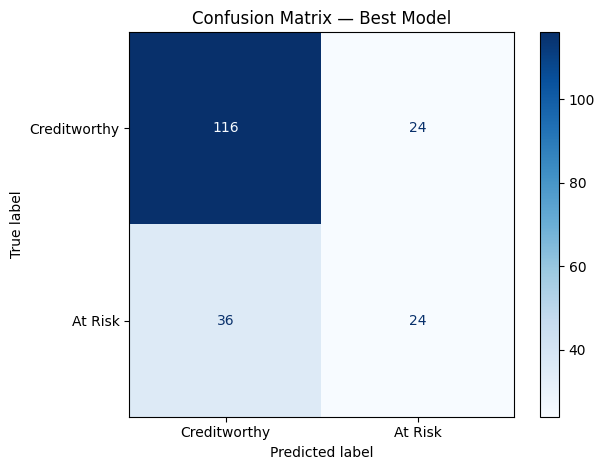

In [20]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Creditworthy", "At Risk"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Best Model")
plt.tight_layout()
plt.show()

In [21]:
# Log the final best model to MLflow
mlflow.set_experiment(experiment_name=EXPERIMENT_NAME)

with mlflow.start_run(run_name="best_model_final_eval"):
    mlflow.log_params(best_params)
    mlflow.log_metric("test_auc", final_auc)
    mlflow.log_metric("test_f1_score", final_f1)

    mlflow.sklearn.log_model(
        rf_best,
        name="model",
        registered_model_name="credit-risk-rf-tuned",
    )
    mlflow.log_artifact(local_path="data/one_hot_encoder.pkl")

    # Save the confusion matrix plot as an artifact
    fig, ax = plt.subplots()
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Creditworthy", "At Risk"]).plot(ax=ax, cmap="Blues")
    fig.savefig("data/confusion_matrix.png", dpi=100, bbox_inches="tight")
    plt.close(fig)
    mlflow.log_artifact("data/confusion_matrix.png")

    print("✅ Best model logged with confusion matrix artifact.")

Successfully registered model 'credit-risk-rf-tuned'.
2026/03/04 11:52:09 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit-risk-rf-tuned, version 1
Created version '1' of model 'credit-risk-rf-tuned'.


✅ Best model logged with confusion matrix artifact.
🏃 View run best_model_final_eval at: http://127.0.0.1:8080/#/experiments/1/runs/538d092a09444f73ba32d171ebd2af17
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


---
## 6 · Model Registry

The MLflow **Model Registry** lets you manage model versions and assign lifecycle stages like *Staging* or *Production*.

> 📖 **Docs:** [MLflow Model Registry](https://mlflow.org/docs/latest/model-registry.html)

### 6.1 Load a model from Model Registry

In [22]:
# ✅ SOLUTION
loaded_model = mlflow.sklearn.load_model("models:/credit-risk-rf-tuned/1")

preds = loaded_model.predict(X_test[:5])
print(f"Sample predictions: {preds}")

Sample predictions: [0 0 1 1 0]


### 6.2 Manage model versions with aliases

Modern MLflow (>= 2.9) uses **model aliases** instead of the deprecated "Stages" system. An alias is a mutable, named reference to a specific model version — for example, you might tag your best model version as `champion`.

> 📖 **Docs:** [Model aliases](https://mlflow.org/docs/latest/model-registry.html#deploy-and-organize-models-with-aliases-and-tags)

**✏️ TODO:** Open the MLflow UI, go to the **Models** tab, find `credit-risk-rf-tuned`, and check which version was created. Then set an alias on it programmatically below.

In [ ]:
# ✅ SOLUTION
client = MlflowClient()

MODEL_NAME = "credit-risk-rf-tuned"
MODEL_VERSION = 1  # Check MLflow UI Models tab for actual version

client.set_registered_model_alias(
    name=MODEL_NAME,
    alias="champion",
    version=MODEL_VERSION,
)
print(f"✅ Alias 'champion' set on {MODEL_NAME} v{MODEL_VERSION}")

### 6.3 Load a model by alias

Now anyone can load the production model using the alias, without needing to know the specific version number or run ID:

In [ ]:
# Load the model using its alias
champion_model = mlflow.sklearn.load_model(f"models:/{MODEL_NAME}@champion")

preds = champion_model.predict(X_test[:5])
print(f"Champion model predictions: {preds}")
print("\n🎉 You have successfully loaded a model from the MLflow Registry!")

**✏️ Question 7 — Why use a Model Registry?**

In a team of data scientists, why is a model registry useful compared to simply saving model files to a shared folder? Think about versioning, reproducibility, and deployment.

---
*✅ Solution:*

A model registry provides:

- **Versioning**: every model version is tracked with its params, metrics, and code.
- **Reproducibility**: each version links to the exact run that produced it.
- **Deployment workflow**: aliases like `champion`/`challenger` provide a structured promotion path.
- **Collaboration**: team members can compare models and make informed deployment decisions.

---

---
## Summary

In this lab, you learned to:

| Step | What you did | MLflow feature used |
|------|-------------|---------------------|
| Setup | Start a tracking server and connect to it | `mlflow server`, `set_tracking_uri()` |
| Baseline | Train a model and log params/metrics/model | `log_param()`, `log_metric()`, `sklearn.log_model()` |
| Manual tuning | Compare runs side by side | MLflow UI comparison view |
| Optuna | Automate search with nested runs | `start_run()` context nesting |
| Artifacts | Log files alongside runs | `log_artifact()` |
| Registry | Version and alias models | `MlflowClient.set_registered_model_alias()` |

**Next lab:** We will move from local MLflow to **Vertex AI on GCP** to track experiments and deploy models in the cloud.